# AGV-Human HRI Simulation (Spawn-First, 10m x 10m Room)

このノートブックは、壁・人・ロボットを最初にスポーンしてからHRI挙動を評価する最小構成です。

前提:
- ルーム境界: $x, y \in [0, 10]$ m
- 壁4辺を明示オブジェクトとしてスポーン
- 人1体とAGV1体を初期位置にスポーン
- スポーン後に時系列シミュレーションを実行

In [ ]:
import math
from dataclasses import dataclass
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
rng = np.random.default_rng(42)

In [2]:
@dataclass
class SimConfig:
    room_size: float = 10.0
    dt: float = 0.1
    duration_s: float = 120.0

    human_speed_mps: float = 0.9
    robot_speed_mps: float = 1.1

    safety_distance_m: float = 0.8
    personal_distance_m: float = 1.2
    interaction_distance_m: float = 3.0

    heading_noise_std_rad: float = 0.08
    human_spawn: Tuple[float, float] = (7.5, 2.0)
    robot_spawn: Tuple[float, float] = (2.0, 8.0)


cfg = SimConfig()
n_steps = int(cfg.duration_s / cfg.dt)

In [3]:
@dataclass
class AgentState:
    name: str
    pos: np.ndarray
    direction: np.ndarray
    speed_mps: float


@dataclass
class Wall:
    name: str
    start: np.ndarray
    end: np.ndarray


def unit(v: np.ndarray) -> np.ndarray:
    norm = np.linalg.norm(v)
    if norm < 1e-9:
        return np.array([1.0, 0.0], dtype=float)
    return v / norm


def clip_to_room(pos: np.ndarray, room_size: float) -> np.ndarray:
    return np.clip(pos, 0.0, room_size)


def reflect_if_wall(pos: np.ndarray, direction: np.ndarray, room_size: float) -> np.ndarray:
    if pos[0] <= 0.0 or pos[0] >= room_size:
        direction[0] *= -1.0
    if pos[1] <= 0.0 or pos[1] >= room_size:
        direction[1] *= -1.0
    return unit(direction)


def choose_random_waypoint(room_size: float) -> np.ndarray:
    return rng.uniform(0.7, room_size - 0.7, size=2)


def spawn_square_room(room_size: float) -> List[Wall]:
    return [
        Wall("south", np.array([0.0, 0.0]), np.array([room_size, 0.0])),
        Wall("east", np.array([room_size, 0.0]), np.array([room_size, room_size])),
        Wall("north", np.array([room_size, room_size]), np.array([0.0, room_size])),
        Wall("west", np.array([0.0, room_size]), np.array([0.0, 0.0])),
    ]


def spawn_agents(config: SimConfig) -> Tuple[AgentState, AgentState]:
    human = AgentState(
        name="human",
        pos=np.array(config.human_spawn, dtype=float),
        direction=unit(np.array([1.0, -0.3], dtype=float)),
        speed_mps=config.human_speed_mps,
    )
    robot = AgentState(
        name="robot",
        pos=np.array(config.robot_spawn, dtype=float),
        direction=unit(np.array([0.6, -1.0], dtype=float)),
        speed_mps=config.robot_speed_mps,
    )
    return human, robot


def spawn_world(config: SimConfig) -> Tuple[Dict[str, object], pd.DataFrame]:
    walls = spawn_square_room(config.room_size)
    human, robot = spawn_agents(config)

    rows = [
        {"entity": "human", "x": human.pos[0], "y": human.pos[1], "info": "spawn"},
        {"entity": "robot", "x": robot.pos[0], "y": robot.pos[1], "info": "spawn"},
    ]

    for wall in walls:
        cx = float((wall.start[0] + wall.end[0]) * 0.5)
        cy = float((wall.start[1] + wall.end[1]) * 0.5)
        rows.append({"entity": f"wall:{wall.name}", "x": cx, "y": cy, "info": "segment-center"})

    world = {
        "room_size": config.room_size,
        "walls": walls,
        "human": human,
        "robot": robot,
    }
    return world, pd.DataFrame(rows)

In [4]:
def simulate_hri(config: SimConfig) -> Tuple[pd.DataFrame, pd.DataFrame, List[Wall]]:
    world, spawn_log = spawn_world(config)

    room = float(world["room_size"] )
    walls = world["walls"]
    human: AgentState = world["human"]
    robot: AgentState = world["robot"]

    human_target = choose_random_waypoint(room)
    rows = []

    n = int(config.duration_s / config.dt)
    for k in range(n):
        t = k * config.dt

        # Human behavior: random waypoint walk.
        to_target = human_target - human.pos
        if np.linalg.norm(to_target) < 0.25:
            human_target = choose_random_waypoint(room)
            to_target = human_target - human.pos

        human.direction = unit(to_target)
        human_noise = rng.normal(0.0, config.heading_noise_std_rad)
        rot_h = np.array(
            [
                [math.cos(human_noise), -math.sin(human_noise)],
                [math.sin(human_noise), math.cos(human_noise)],
            ]
        )
        human.direction = unit(rot_h @ human.direction)

        # Robot behavior: keep social distance and stay interactive.
        rel = human.pos - robot.pos
        dist = np.linalg.norm(rel)

        if dist < config.safety_distance_m:
            desired_robot_dir = -unit(rel)
        elif dist <= config.interaction_distance_m:
            tangent = np.array([-rel[1], rel[0]], dtype=float)
            desired_robot_dir = unit(0.65 * unit(rel) + 0.35 * unit(tangent))
        else:
            desired_robot_dir = unit(rel)

        robot_noise = rng.normal(0.0, config.heading_noise_std_rad)
        rot_r = np.array(
            [
                [math.cos(robot_noise), -math.sin(robot_noise)],
                [math.sin(robot_noise), math.cos(robot_noise)],
            ]
        )
        robot.direction = unit(rot_r @ desired_robot_dir)

        human.pos = human.pos + human.direction * human.speed_mps * config.dt
        robot.pos = robot.pos + robot.direction * robot.speed_mps * config.dt

        human.pos = clip_to_room(human.pos, room)
        robot.pos = clip_to_room(robot.pos, room)
        human.direction = reflect_if_wall(human.pos, human.direction, room)
        robot.direction = reflect_if_wall(robot.pos, robot.direction, room)

        rel = human.pos - robot.pos
        dist = np.linalg.norm(rel)
        in_personal = dist <= config.personal_distance_m
        in_interaction = (config.personal_distance_m < dist) and (dist <= config.interaction_distance_m)

        rows.append(
            {
                "t": t,
                "human_x": human.pos[0],
                "human_y": human.pos[1],
                "robot_x": robot.pos[0],
                "robot_y": robot.pos[1],
                "distance_m": dist,
                "in_personal_space": int(in_personal),
                "in_interaction_zone": int(in_interaction),
            }
        )

    return spawn_log, pd.DataFrame(rows), walls

In [5]:
spawn_log, df, walls = simulate_hri(cfg)
display(spawn_log)
df.head()

,t,robot_x,robot_y,human_x,human_y,distance_m,in_personal_space,in_interaction_zone
0,0.0,2.080215,7.924730,7.493339,2.089753,7.959200,0,0
1,0.1,2.146236,7.836746,7.506284,2.178817,7.793733,0,0
2,0.2,2.219843,7.755002,7.503752,2.268782,7.616975,0,0
3,0.3,2.290570,7.670754,7.502299,2.358770,7.441727,0,0
4,0.4,2.372340,7.597177,7.494399,2.448423,7.262586,0,0


In [6]:
def summarize_hri_metrics(df: pd.DataFrame, config: SimConfig) -> pd.DataFrame:
    dt = config.dt
    d = df["distance_m"].to_numpy()

    safety_crossings = int(
        np.sum((d[:-1] >= config.safety_distance_m) & (d[1:] < config.safety_distance_m))
    )

    metrics = {
        "duration_s": config.duration_s,
        "mean_distance_m": float(df["distance_m"].mean()),
        "min_distance_m": float(df["distance_m"].min()),
        "max_distance_m": float(df["distance_m"].max()),
        "personal_space_time_s": float(df["in_personal_space"].sum() * dt),
        "interaction_zone_time_s": float(df["in_interaction_zone"].sum() * dt),
        "personal_space_ratio": float(df["in_personal_space"].mean()),
        "interaction_zone_ratio": float(df["in_interaction_zone"].mean()),
        "safety_boundary_crossings": safety_crossings,
    }

    out = pd.DataFrame([metrics]).T.reset_index()
    out.columns = ["metric", "value"]
    return out


summary = summarize_hri_metrics(df, cfg)
summary

,metric,value
0,duration_s,120.000000
1,mean_distance_m,0.974862
2,min_distance_m,0.618843
3,max_distance_m,7.959200
4,personal_space_time_s,115.700000
5,interaction_zone_time_s,1.300000
6,personal_space_ratio,0.964167
7,interaction_zone_ratio,0.010833
8,safety_boundary_crossings,195.000000


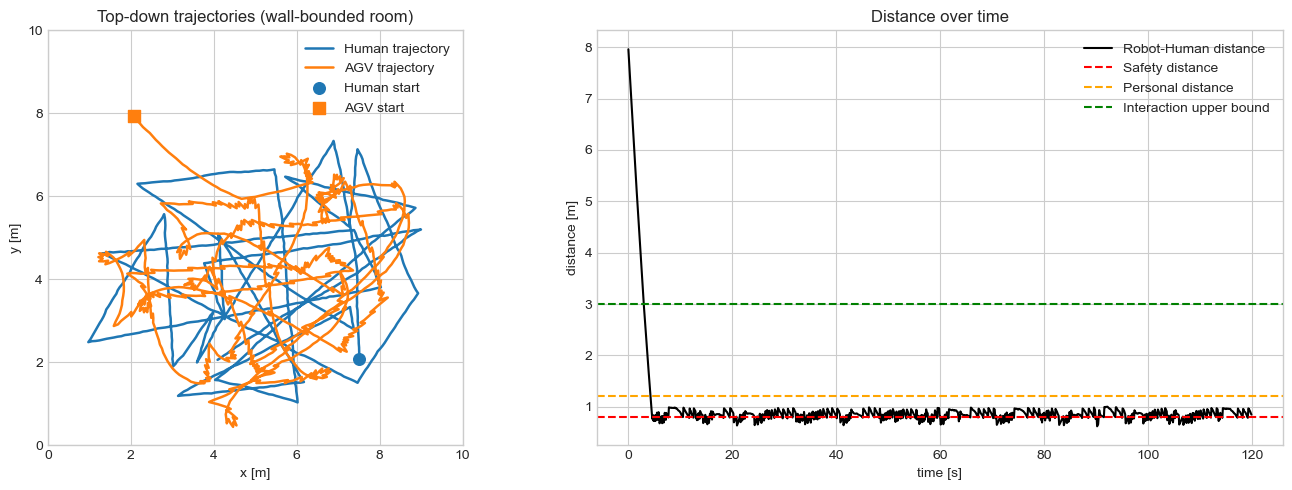

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: spawned walls and trajectories.
for wall in walls:
    xs = [wall.start[0], wall.end[0]]
    ys = [wall.start[1], wall.end[1]]
    axes[0].plot(xs, ys, color="dimgray", linewidth=4, solid_capstyle="round")

axes[0].plot(df["human_x"], df["human_y"], label="Human trajectory", linewidth=1.8)
axes[0].plot(df["robot_x"], df["robot_y"], label="AGV trajectory", linewidth=1.8)

axes[0].scatter(
    df["human_x"].iloc[0],
    df["human_y"].iloc[0],
    marker="o",
    s=80,
    label="Human spawn",
    zorder=5,
 )
axes[0].scatter(
    df["robot_x"].iloc[0],
    df["robot_y"].iloc[0],
    marker="s",
    s=80,
    label="AGV spawn",
    zorder=5,
 )

axes[0].set_xlim(-0.2, cfg.room_size + 0.2)
axes[0].set_ylim(-0.2, cfg.room_size + 0.2)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("Spawned room, human, and AGV")
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
axes[0].legend(loc="upper right")

# Right: distance profile with social zones.
axes[1].plot(df["t"], df["distance_m"], color="black", linewidth=1.5, label="Robot-human distance")
axes[1].axhline(cfg.safety_distance_m, color="red", linestyle="--", label="Safety distance")
axes[1].axhline(cfg.personal_distance_m, color="orange", linestyle="--", label="Personal distance")
axes[1].axhline(cfg.interaction_distance_m, color="green", linestyle="--", label="Interaction upper bound")

axes[1].set_title("Distance over time")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("distance [m]")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [8]:
df["hri_label"] = np.where(
    df["distance_m"] < cfg.safety_distance_m,
    "unsafe-close",
    np.where(df["distance_m"] <= cfg.interaction_distance_m, "interaction-range", "far"),
)

df[["t", "distance_m", "hri_label"]].head(20)

,t,distance_m,hri_label
0,0.0,7.959200,far
1,0.1,7.793733,far
2,0.2,7.616975,far
3,0.3,7.441727,far
4,0.4,7.262586,far
5,0.5,7.088185,far
6,0.6,6.912236,far
7,0.7,6.737583,far
8,0.8,6.560763,far
9,0.9,6.390434,far


## 次の拡張案

- UE接続時に、同じspawnログから実際のアクターSpawnコマンドを生成する。
- 人の行動モードを追加（待機、すれ違い、目的地優先）。
- AGVにタスク優先度を導入（到達時間と快適距離の重み切替）。
- 1対1から複数人・複数ロボットへ拡張。